# BIRD Targeted-SFT MiniDev500 Final Evaluation v1

This notebook performs the next controlled experiment after Targeted-SFT training.

It **does not rerun** the four existing Base/Original-SFT conditions. It reads their saved five-candidate result CSVs, loads exactly one fresh Base model with the **Targeted-SFT LoRA adapter**, evaluates Targeted-SFT both without and with BIRD evidence, and produces a six-condition comparison.

Primary comparison:

- Original SFT + Evidence versus Targeted SFT + Evidence

Secondary controls:

- no-evidence performance;
- Base-model reference performance;
- EX@1, Oracle@3, Oracle@5, Valid SQL, difficulty and database breakdowns;
- paired improvements/regressions, exact McNemar tests, and paired bootstrap confidence intervals.

Candidate 1 is greedy and defines EX@1. Candidates 2–5 are reproducible samples. Oracle@K is an upper bound, not deployable accuracy.

> MiniDev500 was already used for failure-mode analysis. Treat this as an iterative development benchmark, not an untouched blind test.

## 0. Controlled protocol and runtime scope

- Dataset: classic BIRD Mini-Dev 500, pinned to the same revision used by the previous four-way notebook.
- Prompt, schema rendering, evidence handling, SQL extraction, SQLite execution semantics, generation length, sampling temperature/top-p, and random seeds remain unchanged.
- Existing Base and Original-SFT predictions are loaded from disk; only the two Targeted-SFT conditions are generated.
- GPU memory contains one BF16 Base model plus one Targeted LoRA adapter. The Original-SFT adapter is never loaded.
- The two new conditions cover 1,000 prompts and 5,000 SQL candidates. Results are saved every five examples and can resume safely.

## 1. Install pinned dependencies

In [22]:
%pip install -q -U \
    "transformers==5.14.1" \
    "peft==0.20.0" \
    "accelerate==1.14.0" \
    "datasets==5.0.1" \
    "gdown>=5.2" \
    "sqlglot>=26.0" \
    "scipy>=1.11" \
    pandas matplotlib seaborn tqdm

## 2. Imports, seeds, GPU, and Google Drive

In [23]:
import gc
import hashlib
import json
import math
import os
import random
import re
import shutil
import sqlite3
import statistics
import time
import warnings
import zipfile
from pathlib import Path
from urllib.parse import quote

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlglot
import torch
from datasets import load_dataset
from IPython.display import display
from peft import PeftConfig, PeftModel
from scipy.stats import binomtest
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    set_seed,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("No GPU was detected. In Colab, select Runtime → Change runtime type → GPU.")

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)
print("BF16 supported:", torch.cuda.is_bf16_supported())

from google.colab import drive
drive.mount("/content/drive")

GPU: NVIDIA A100-SXM4-40GB
CUDA: 12.8
BF16 supported: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Isolated paths and experiment controls

The old four-way result directory is read-only in this notebook. All new Targeted-SFT predictions and comparisons are written to a new result directory.

In [24]:
# ========================= PROJECT LAYOUT =========================
PROJECT_ROOT = Path("/content/drive/MyDrive/bird-text2sql-sft")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = PROJECT_ROOT / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

ORIGINAL_FOUR_WAY_DIR = RESULTS_DIR / "minidev500_ex1_oracle3_oracle5_four_way"

TARGETED_TRAINING_RUN_DIR = (
    PROJECT_ROOT
    / "training"
    / "qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192"
)
TARGETED_ADAPTER_DIR = TARGETED_TRAINING_RUN_DIR / "final_adapter"
TARGETED_TRAINING_CONFIG_PATH = TARGETED_TRAINING_RUN_DIR / "run_config.json"

PROJECT_DIR = RESULTS_DIR / "minidev500_targeted_sft_final_comparison_v1"

for directory in [DATA_DIR, PROCESSED_DIR, RESULTS_DIR, PROJECT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
# ==================================================================

BASE_MODEL_ID = "Qwen/Qwen2.5-Coder-7B-Instruct"

HF_DATASET_ID = "birdsql/bird_mini_dev"
HF_REVISION = "f65faf4ae3b638c1fa6df1d3370c8d92c8366301"
HF_SPLIT = "mini_dev_sqlite"
OFFICIAL_DB_GOOGLE_DRIVE_ID = "13VLWIwpw5E3d5DUkMvzw7hvHE67a4XkG"

LOCAL_DATA_ROOT = DATA_DIR / "bird_minidev500"
LOCAL_ZIP_PATH = LOCAL_DATA_ROOT / "minidev_0703.zip"
LOCAL_EXTRACT_DIR = LOCAL_DATA_ROOT / "extracted"
HF_CACHE_DIR = DATA_DIR / "hf_cache"

LOAD_IN_4BIT = False
MAX_INPUT_TOKENS = 8192
MAX_NEW_TOKENS = 256
SQL_TIMEOUT_SECONDS = 30.0

NUM_CANDIDATES = 5
ORACLE_K_VALUES = (1, 3, 5)
NUM_SAMPLED_CANDIDATES = NUM_CANDIDATES - 1
SAMPLING_TEMPERATURE = 0.7
SAMPLING_TOP_P = 0.95

RUN_TARGETED = True
RESUME = True
FORCE_RESTART = False
SAVE_EVERY = 5
DEBUG_LIMIT = None  # Set to 5 only for a smoke test; restore None for the full run.

PROMPT_VERSION = "bird_schema_evidence_ablation_chat_v2"
SEED = 42

REFERENCE_EXPERIMENTS = {
    "baseline_no_evidence": {"model_type": "baseline", "use_evidence": False},
    "baseline_with_evidence": {"model_type": "baseline", "use_evidence": True},
    "sft_no_evidence": {"model_type": "sft", "use_evidence": False},
    "sft_with_evidence": {"model_type": "sft", "use_evidence": True},
}
TARGETED_EXPERIMENTS = {
    "targeted_sft_no_evidence": {"model_type": "targeted_sft", "use_evidence": False},
    "targeted_sft_with_evidence": {"model_type": "targeted_sft", "use_evidence": True},
}
EXPERIMENTS = {**REFERENCE_EXPERIMENTS, **TARGETED_EXPERIMENTS}

assert NUM_CANDIDATES == max(ORACLE_K_VALUES)
assert tuple(sorted(ORACLE_K_VALUES)) == ORACLE_K_VALUES

print("Reference results:", ORIGINAL_FOUR_WAY_DIR)
print("Targeted adapter:", TARGETED_ADAPTER_DIR)
print("New results:", PROJECT_DIR)

Reference results: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_ex1_oracle3_oracle5_four_way
Targeted adapter: /content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192/final_adapter
New results: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_targeted_sft_final_comparison_v1


## 4. Verify the Targeted-SFT adapter, selected checkpoint, and reference files

In [25]:
required_adapter_files = [
    TARGETED_ADAPTER_DIR / "adapter_config.json",
    TARGETED_ADAPTER_DIR / "adapter_model.safetensors",
]
missing_adapter_files = [str(path) for path in required_adapter_files if not path.exists()]
if missing_adapter_files:
    raise FileNotFoundError(f"Targeted final_adapter is incomplete: {missing_adapter_files}")

if not TARGETED_TRAINING_CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing Targeted-SFT run_config.json: {TARGETED_TRAINING_CONFIG_PATH}")

TARGETED_TRAINING_CONFIG = json.loads(
    TARGETED_TRAINING_CONFIG_PATH.read_text(encoding="utf-8")
)

if TARGETED_TRAINING_CONFIG.get("model_id") != BASE_MODEL_ID:
    raise RuntimeError("Targeted-SFT base model does not match the evaluation base model.")
if int(TARGETED_TRAINING_CONFIG.get("max_length", -1)) != MAX_INPUT_TOKENS:
    raise RuntimeError("Targeted-SFT max_length does not match this evaluation.")
if TARGETED_TRAINING_CONFIG.get("prompt_version") != PROMPT_VERSION:
    raise RuntimeError("Targeted-SFT prompt version does not match this evaluation.")

selected_step = int(TARGETED_TRAINING_CONFIG["selected_checkpoint_step"])
selected_path = Path(TARGETED_TRAINING_CONFIG["selected_checkpoint"])
if selected_path.name != f"checkpoint-{selected_step}":
    raise RuntimeError("run_config selected checkpoint path/step mismatch.")

peft_config = PeftConfig.from_pretrained(str(TARGETED_ADAPTER_DIR))
if peft_config.base_model_name_or_path != BASE_MODEL_ID:
    raise RuntimeError(
        f"Adapter base mismatch: {peft_config.base_model_name_or_path} != {BASE_MODEL_ID}"
    )

reference_paths = {
    label: ORIGINAL_FOUR_WAY_DIR / f"{label}_minidev500_results.csv"
    for label in REFERENCE_EXPERIMENTS
}
missing_reference_files = [str(path) for path in reference_paths.values() if not path.exists()]
if missing_reference_files:
    raise FileNotFoundError(
        "The previous five-candidate four-way results are required and will not be regenerated. "
        f"Missing: {missing_reference_files}"
    )

print("Selected checkpoint step:", selected_step)
print("Selected held-out macro-EX:", TARGETED_TRAINING_CONFIG["selected_checkpoint_macro_ex"])
print("Training peak GPU memory (GB):", TARGETED_TRAINING_CONFIG.get("peak_gpu_memory_gb"))
print("All four reference result files are present.")

Selected checkpoint step: 600
Selected held-out macro-EX: 0.59
Training peak GPU memory (GB): 24.29136323928833
All four reference result files are present.


## 5. Load and pin the official MiniDev500 snapshot

In [26]:
dataset_dict = load_dataset(
    HF_DATASET_ID,
    revision=HF_REVISION,
    cache_dir=str(HF_CACHE_DIR),
)

if HF_SPLIT not in dataset_dict:
    raise KeyError(f"Could not find split={HF_SPLIT}; available splits: {list(dataset_dict.keys())}")

raw_split = dataset_dict[HF_SPLIT]
print(raw_split)
print("Columns:", raw_split.column_names)


def first_present(example, names, default=None):
    for name in names:
        if name in example and example[name] is not None:
            return example[name]
    return default


records = []
for position, example in enumerate(raw_split):
    gold_sql = first_present(example, ["SQL", "sql", "query", "gold_sql"])
    if gold_sql is None:
        raise KeyError(f"Gold SQL was not found for example {position}. Fields={list(example.keys())}")

    records.append({
        "position": position,
        "source_index": first_present(example, ["index", "idx", "id"], position),
        "db_id": str(first_present(example, ["db_id", "database_id"])),
        "question": str(first_present(example, ["question", "utterance"])),
        "evidence": str(first_present(example, ["evidence", "external_knowledge"], "") or ""),
        "gold_sql": str(gold_sql).strip(),
        "difficulty": str(first_present(example, ["difficulty", "level"], "unknown")).lower(),
    })

eval_df = pd.DataFrame(records)

assert len(eval_df) == 500, f"Expected 500 examples, found {len(eval_df)}"
assert eval_df["db_id"].nunique() == 11, (
    f"Expected 11 databases, found {eval_df['db_id'].nunique()}"
)
assert eval_df["question"].notna().all()
assert eval_df["gold_sql"].str.len().gt(0).all()

dataset_payload = eval_df.to_json(orient="records", force_ascii=False)
DATASET_SHA256 = hashlib.sha256(dataset_payload.encode("utf-8")).hexdigest()

# Store the pinned, normalized 500-example evaluation snapshot under processed/.
snapshot_path = PROCESSED_DIR / "mini_dev_500_snapshot.jsonl"
eval_df.to_json(
    snapshot_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("Rows:", len(eval_df))
print("Databases:", eval_df["db_id"].nunique())
print("Dataset SHA256:", DATASET_SHA256)
print("Processed snapshot:", snapshot_path)
display(eval_df.head(3))
display(eval_df["difficulty"].value_counts(dropna=False).rename("count").to_frame())
display(eval_df["db_id"].value_counts().sort_index().rename("count").to_frame())

Dataset({
    features: ['question_id', 'db_id', 'question', 'evidence', 'SQL', 'difficulty'],
    num_rows: 500
})
Columns: ['question_id', 'db_id', 'question', 'evidence', 'SQL', 'difficulty']
Rows: 500
Databases: 11
Dataset SHA256: c38826f6825c30bd2d3916f30dab8f259e149bf9ca8d2d0bb454d8493105b52c
Processed snapshot: /content/drive/MyDrive/bird-text2sql-sft/processed/mini_dev_500_snapshot.jsonl


,position,source_index,db_id,question,evidence,gold_sql,difficulty
0,0,0,debit_card_specializing,What is the ratio of customers who pay in EUR against customers who pay in CZK?,ratio of customers who pay in EUR against customers who pay in CZK = count(Currency = 'EUR') / count(Currency = 'CZK').,"SELECT CAST(SUM(IIF(Currency = 'EUR', 1, 0)) AS FLOAT) / SUM(IIF(Currency = 'CZK', 1, 0)) AS ratio FROM customers",simple
1,1,1,debit_card_specializing,"In 2012, who had the least consumption in LAM?",Year 2012 can be presented as Between 201201 And 201212; The first 4 strings of the Date values in the yearmonth table can represent year.,"SELECT T1.CustomerID FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE T1.Segment = 'LAM' AND SUBSTR(T2.Date, 1, 4) = '...",moderate
2,2,2,debit_card_specializing,What was the average monthly consumption of customers in SME for the year 2013?,Average Monthly consumption = AVG(Consumption) / 12; Year 2013 can be presented as Between 201301 And 201312; The first 4 strings of the Date values in the ...,"SELECT AVG(T2.Consumption) / 12 FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE SUBSTR(T2.Date, 1, 4) = '2013' AND T1...",moderate


,count
difficulty,
moderate,250
simple,148
challenging,102


,count
db_id,
california_schools,30
card_games,52
codebase_community,49
debit_card_specializing,30
european_football_2,51
financial,32
formula_1,66
student_club,48
superhero,52


## 6. Download and extract the official SQLite databases

In [27]:
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

if not LOCAL_ZIP_PATH.exists():
    print("Downloading the database package from the official BIRD Google Drive...")
    downloaded = gdown.download(
        id=OFFICIAL_DB_GOOGLE_DRIVE_ID,
        output=str(LOCAL_ZIP_PATH),
        quiet=False,
    )
    if downloaded is None or not LOCAL_ZIP_PATH.exists():
        raise RuntimeError("The database package download failed. Rerun this cell.")
else:
    print("The archive already exists; skipping download:", LOCAL_ZIP_PATH)

if not zipfile.is_zipfile(LOCAL_ZIP_PATH):
    raise RuntimeError(f"The downloaded file is not a valid ZIP archive: {LOCAL_ZIP_PATH}")

extract_marker = LOCAL_EXTRACT_DIR / ".extraction_complete"
if not extract_marker.exists():
    if LOCAL_EXTRACT_DIR.exists():
        shutil.rmtree(LOCAL_EXTRACT_DIR)
    LOCAL_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    print("Extracting the archive...")
    with zipfile.ZipFile(LOCAL_ZIP_PATH) as zf:
        zf.extractall(LOCAL_EXTRACT_DIR)
    extract_marker.touch()
    print("Extraction completed:", LOCAL_EXTRACT_DIR)
else:
    print("The archive is already extracted; skipping:", LOCAL_EXTRACT_DIR)

The archive already exists; skipping download: /content/drive/MyDrive/bird-text2sql-sft/data/bird_minidev500/minidev_0703.zip
The archive is already extracted; skipping: /content/drive/MyDrive/bird-text2sql-sft/data/bird_minidev500/extracted


## 7. Resolve and cache all 11 databases on the Colab SSD

In [28]:
import shutil
import sqlite3
from pathlib import Path
from urllib.parse import quote

# Requirements:
# 1. eval_df has already been created.
# 2. LOCAL_EXTRACT_DIR points to the extracted Mini-Dev database directory.

assert "eval_df" in globals(), "Run the Mini-Dev dataset loading cell first."
assert "LOCAL_EXTRACT_DIR" in globals(), (
    "Run the database download and extraction cell first."
)
assert LOCAL_EXTRACT_DIR.exists(), (
    f"Database directory does not exist: {LOCAL_EXTRACT_DIR}"
)


def collect_sqlite_files(root: Path):
    """Find SQLite database files under the extracted directory."""
    suffixes = {".sqlite", ".sqlite3", ".db"}

    return sorted(
        path
        for path in root.rglob("*")
        if path.is_file() and path.suffix.lower() in suffixes
    )


def resolve_db_path(db_id: str, candidates):
    """Find the SQLite file corresponding to one BIRD db_id."""

    # Preferred structure: .../<db_id>/<db_id>.sqlite
    preferred = [
        path
        for path in candidates
        if path.stem == db_id and path.parent.name == db_id
    ]
    if preferred:
        return min(preferred, key=lambda path: len(str(path)))

    # Match the filename, such as california_schools.sqlite
    stem_matches = [
        path for path in candidates
        if path.stem == db_id
    ]
    if stem_matches:
        return min(stem_matches, key=lambda path: len(str(path)))

    # Match the parent directory.
    parent_matches = [
        path for path in candidates
        if path.parent.name == db_id
    ]
    if parent_matches:
        return min(parent_matches, key=lambda path: len(str(path)))

    raise FileNotFoundError(
        f"Could not find a SQLite file for db_id={db_id}"
    )


# Step 1: Locate the source databases.
sqlite_files = collect_sqlite_files(LOCAL_EXTRACT_DIR)

print("SQLite-like files found:", len(sqlite_files))

if not sqlite_files:
    raise FileNotFoundError(
        f"No SQLite files were found under {LOCAL_EXTRACT_DIR}"
    )

db_ids = sorted(eval_df["db_id"].dropna().unique())

print("Unique database IDs in Mini-Dev:", len(db_ids))
assert len(db_ids) == 11, (
    f"Expected 11 Mini-Dev databases, but found {len(db_ids)}"
)

SOURCE_DB_PATHS = {
    db_id: resolve_db_path(db_id, sqlite_files)
    for db_id in db_ids
}

print("All source databases were resolved.")


# Step 2: Copy the 11 databases to the local Colab SSD.
LOCAL_DB_CACHE = Path("/content/bird_minidev500_sqlite")
LOCAL_DB_CACHE.mkdir(parents=True, exist_ok=True)

DB_PATHS = {}

for position, db_id in enumerate(db_ids, start=1):
    source_path = SOURCE_DB_PATHS[db_id]

    target_dir = LOCAL_DB_CACHE / db_id
    target_dir.mkdir(parents=True, exist_ok=True)

    target_path = target_dir / source_path.name

    source_size = source_path.stat().st_size
    target_is_complete = (
        target_path.exists()
        and target_path.stat().st_size == source_size
    )

    if target_is_complete:
        status = "cached"
    else:
        shutil.copy2(source_path, target_path)
        status = "copied"

    DB_PATHS[db_id] = target_path

    print(
        f"[{position:02d}/{len(db_ids)}] "
        f"{db_id}: {status} "
        f"({source_size / 1024**2:.2f} MB)"
    )


# Step 3: Perform only a fast database-opening check.
health_rows = []

for db_id, db_path in DB_PATHS.items():
    uri = f"file:{quote(str(db_path.resolve()))}?mode=ro"

    with sqlite3.connect(uri, uri=True, timeout=10) as connection:
        table_count = connection.execute(
            """
            SELECT COUNT(*)
            FROM sqlite_master
            WHERE type = 'table'
              AND name NOT LIKE 'sqlite_%'
            """
        ).fetchone()[0]

    health_rows.append(
        {
            "db_id": db_id,
            "db_path": str(db_path),
            "storage": "Colab local SSD",
            "table_count": table_count,
            "size_mb": round(db_path.stat().st_size / 1024**2, 2),
        }
    )

    print(f"Opened {db_id}: {table_count} tables")


db_health_df = pd.DataFrame(health_rows)

assert len(DB_PATHS) == 11
assert all(path.exists() for path in DB_PATHS.values())
assert db_health_df["table_count"].gt(0).all(), db_health_df

display(db_health_df)

print("DB_PATHS has been created successfully.")
print("All evaluation queries will use the local Colab SSD.")

SQLite-like files found: 22
Unique database IDs in Mini-Dev: 11
All source databases were resolved.
[01/11] california_schools: cached (10.60 MB)
[02/11] card_games: cached (249.69 MB)
[03/11] codebase_community: cached (459.12 MB)
[04/11] debit_card_specializing: cached (33.03 MB)
[05/11] european_football_2: cached (570.06 MB)
[06/11] financial: cached (67.99 MB)
[07/11] formula_1: cached (21.32 MB)
[08/11] student_club: cached (2.52 MB)
[09/11] superhero: cached (0.23 MB)
[10/11] thrombosis_prediction: cached (6.99 MB)
[11/11] toxicology: cached (2.55 MB)
Opened california_schools: 3 tables
Opened card_games: 6 tables
Opened codebase_community: 8 tables
Opened debit_card_specializing: 5 tables
Opened european_football_2: 7 tables
Opened financial: 8 tables
Opened formula_1: 13 tables
Opened student_club: 8 tables
Opened superhero: 10 tables
Opened thrombosis_prediction: 3 tables
Opened toxicology: 4 tables


,db_id,db_path,storage,table_count,size_mb
0,california_schools,/content/bird_minidev500_sqlite/california_schools/california_schools.sqlite,Colab local SSD,3,10.60
1,card_games,/content/bird_minidev500_sqlite/card_games/card_games.sqlite,Colab local SSD,6,249.69
2,codebase_community,/content/bird_minidev500_sqlite/codebase_community/codebase_community.sqlite,Colab local SSD,8,459.12
3,debit_card_specializing,/content/bird_minidev500_sqlite/debit_card_specializing/debit_card_specializing.sqlite,Colab local SSD,5,33.03
4,european_football_2,/content/bird_minidev500_sqlite/european_football_2/european_football_2.sqlite,Colab local SSD,7,570.06
5,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,Colab local SSD,8,67.99
6,formula_1,/content/bird_minidev500_sqlite/formula_1/formula_1.sqlite,Colab local SSD,13,21.32
7,student_club,/content/bird_minidev500_sqlite/student_club/student_club.sqlite,Colab local SSD,8,2.52
8,superhero,/content/bird_minidev500_sqlite/superhero/superhero.sqlite,Colab local SSD,10,0.23
9,thrombosis_prediction,/content/bird_minidev500_sqlite/thrombosis_prediction/thrombosis_prediction.sqlite,Colab local SSD,3,6.99


DB_PATHS has been created successfully.
All evaluation queries will use the local Colab SSD.


In [29]:
assert len(DB_PATHS) == 11
assert all(path.exists() for path in DB_PATHS.values())

print("All 11 databases are ready on the local Colab disk.")

All 11 databases are ready on the local Colab disk.


## 8. Build the controlled schema/evidence prompts

In [30]:
SCHEMA_CACHE = {}


def get_sqlite_schema(db_path):
    cache_key = str(Path(db_path).resolve())
    if cache_key in SCHEMA_CACHE:
        return SCHEMA_CACHE[cache_key]

    uri = f"file:{quote(cache_key)}?mode=ro"
    with sqlite3.connect(uri, uri=True) as conn:
        rows = conn.execute(
            '''
            SELECT name, sql
            FROM sqlite_master
            WHERE type = 'table'
              AND name NOT LIKE 'sqlite_%'
              AND sql IS NOT NULL
            ORDER BY name
            '''
        ).fetchall()

    schema = "\n\n".join(sql.strip() + ";" for _, sql in rows)
    SCHEMA_CACHE[cache_key] = schema
    return schema


SYSTEM_PROMPT = (
    "You are an expert SQLite developer. "
    "Given a database schema, a question, and optional evidence, "
    "write one valid SQLite query that answers the question. "
    "Return only the SQL query without explanations or Markdown."
)


def build_messages(record, use_evidence):
    schema = get_sqlite_schema(DB_PATHS[record["db_id"]])
    evidence = record.get("evidence", "").strip()
    evidence_block = evidence if (use_evidence and evidence) else "None"

    user_prompt = f'''Database ID:
{record['db_id']}

SQLite schema:
{schema}

External knowledge:
{evidence_block}

Question:
{record['question']}

Write exactly one executable SQLite query that answers the question. Return SQL only.'''

    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]


preview_record = eval_df.iloc[0].to_dict()
print("NO-EVIDENCE PROMPT:")
print(json.dumps(build_messages(preview_record, False), ensure_ascii=False, indent=2))
print("\nWITH-EVIDENCE PROMPT:")
print(json.dumps(build_messages(preview_record, True), ensure_ascii=False, indent=2))

evidence_coverage = eval_df["evidence"].fillna("").str.strip().ne("").mean()
print(f"\nNon-empty BIRD evidence: {evidence_coverage:.1%}")

NO-EVIDENCE PROMPT:
[
  {
    "role": "system",
    "content": "You are an expert SQLite developer. Given a database schema, a question, and optional evidence, write one valid SQLite query that answers the question. Return only the SQL query without explanations or Markdown."
  },
  {
    "role": "user",
    "content": "Database ID:\ndebit_card_specializing\n\nSQLite schema:\nCREATE TABLE customers\n(\n    CustomerID INTEGER UNIQUE     not null\n        primary key,\n    Segment    TEXT null,\n    Currency   TEXT null\n);\n\nCREATE TABLE gasstations\n(\n    GasStationID INTEGER    UNIQUE   not null\n        primary key,\n    ChainID      INTEGER          null,\n    Country      TEXT null,\n    Segment      TEXT null\n);\n\nCREATE TABLE products\n(\n    ProductID   INTEGER   UNIQUE      not null\n        primary key,\n    Description TEXT null\n);\n\nCREATE TABLE \"transactions_1k\"\n(\n    TransactionID INTEGER\n        primary key autoincrement,\n    Date          DATE,\n    Time     

## 9. SQL extraction and official execution semantics

In [31]:
def first_sql_statement(text):
    '''Keep the first SQL statement and ignore semicolons inside quoted strings.'''
    quote_char = None
    i = 0
    while i < len(text):
        ch = text[i]
        if quote_char is None:
            if ch in {"'", '"', '`'}:
                quote_char = ch
            elif ch == ";":
                return text[: i + 1]
        else:
            if ch == quote_char:
                # Two consecutive quote characters in SQL represent an escaped quote
                if i + 1 < len(text) and text[i + 1] == quote_char:
                    i += 1
                else:
                    quote_char = None
        i += 1
    return text


def extract_sql(raw_text):
    text = (raw_text or "").strip()
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.IGNORECASE | re.DOTALL).strip()

    fenced = re.search(
        r"```(?:sql|sqlite)?\s*(.*?)```",
        text,
        flags=re.IGNORECASE | re.DOTALL,
    )
    if fenced:
        text = fenced.group(1).strip()

    start = re.search(r"\b(?:SELECT|WITH)\b", text, flags=re.IGNORECASE)
    if start:
        text = text[start.start():]

    text = first_sql_statement(text).strip()
    text = re.sub(r"\s*(?:<\|im_end\|>|<\|endoftext\|>)\s*$", "", text).strip()
    return text


def normalize_sql(sql):
    if not sql or not sql.strip():
        return ""
    try:
        parsed = sqlglot.parse_one(sql, read="sqlite")
        return parsed.sql(dialect="sqlite", pretty=False, normalize=True).strip().lower()
    except Exception:
        fallback = re.sub(r"\s+", " ", sql.strip().rstrip(";"))
        return fallback.lower()


def execute_read_only(db_path, sql, timeout_seconds=30.0):
    '''Execute a query through a read-only SQLite connection with a progress-handler timeout.'''
    if not sql or not sql.strip():
        return None, 0.0, "empty SQL"

    start_time = time.perf_counter()
    deadline = start_time + timeout_seconds
    uri = f"file:{quote(str(Path(db_path).resolve()))}?mode=ro"
    conn = None
    try:
        conn = sqlite3.connect(uri, uri=True, timeout=timeout_seconds)
        conn.execute("PRAGMA query_only = ON")
        conn.set_progress_handler(lambda: 1 if time.perf_counter() > deadline else 0, 10_000)
        rows = conn.execute(sql).fetchall()
        elapsed = time.perf_counter() - start_time
        return rows, elapsed, ""
    except Exception as exc:
        elapsed = time.perf_counter() - start_time
        message = str(exc)
        if "interrupted" in message.lower() and time.perf_counter() >= deadline:
            message = f"timeout after {timeout_seconds:.1f}s"
        return None, elapsed, message
    finally:
        if conn is not None:
            conn.close()


def official_execution_equal(predicted_rows, gold_rows):
    '''Match the official BIRD Mini-Dev evaluation_ex.py semantics: set(pred) == set(gold).'''
    if predicted_rows is None or gold_rows is None:
        return False
    return set(predicted_rows) == set(gold_rows)


# Run a Gold SQL sanity check to catch an incorrect database package or mapping.
gold_check_rows = []
for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Gold SQL sanity check"):
    result, elapsed, error = execute_read_only(
        DB_PATHS[row["db_id"]],
        row["gold_sql"],
        SQL_TIMEOUT_SECONDS,
    )
    gold_check_rows.append({
        "position": int(row["position"]),
        "gold_valid": result is not None,
        "gold_execution_seconds": elapsed,
        "gold_error": error,
    })

gold_check_df = pd.DataFrame(gold_check_rows)
display(gold_check_df["gold_valid"].value_counts(dropna=False).rename("count").to_frame())

if not gold_check_df["gold_valid"].all():
    display(gold_check_df.loc[~gold_check_df["gold_valid"]].head(20))
    raise RuntimeError(
        "At least one Gold SQL query could not be executed. Check the database package, db_id mapping, and SQLite version."
    )

Gold SQL sanity check:   0%|          | 0/500 [00:00<?, ?it/s]

,count
gold_valid,
True,500


## 10. Load one Base model with one Targeted LoRA and generate five candidates

The Original-SFT model is never loaded. Reference conditions are CSV files only.

In [32]:
COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16


def make_quantization_config():
    if not LOAD_IN_4BIT:
        return None
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    )


def load_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(
        BASE_MODEL_ID,
        cache_dir=str(HF_CACHE_DIR),
        use_fast=True,
    )
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    tokenizer.truncation_side = "left"
    return tokenizer


def load_targeted_eval_model():
    """Load exactly one Base model and attach only the Targeted-SFT LoRA adapter."""
    kwargs = dict(
        cache_dir=str(HF_CACHE_DIR),
        device_map="auto",
        torch_dtype=COMPUTE_DTYPE,
        low_cpu_mem_usage=True,
    )
    quant_config = make_quantization_config()
    if quant_config is not None:
        kwargs["quantization_config"] = quant_config

    base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, **kwargs)
    model = PeftModel.from_pretrained(
        base_model,
        str(TARGETED_ADAPTER_DIR),
        is_trainable=False,
    )
    model.eval()
    return model

def model_input_device(model):
    return model.get_input_embeddings().weight.device


def generated_token_count(token_ids, eos_token_id):
    if eos_token_id is None:
        return int(token_ids.numel())
    eos_positions = (token_ids == eos_token_id).nonzero(as_tuple=False)
    if len(eos_positions):
        return int(eos_positions[0].item() + 1)
    return int(token_ids.numel())


def decode_candidate_batch(output_ids, input_token_count, tokenizer, rank_offset):
    candidates = []
    for batch_index, sequence_ids in enumerate(output_ids):
        new_ids = sequence_ids[input_token_count:]
        raw_generation = tokenizer.decode(new_ids, skip_special_tokens=True)
        candidates.append({
            "rank": int(rank_offset + batch_index),
            "raw_generation": raw_generation,
            "predicted_sql": extract_sql(raw_generation),
            "output_token_count": generated_token_count(
                new_ids, tokenizer.eos_token_id
            ),
        })
    return candidates


@torch.inference_mode()
def generate_candidates(model, tokenizer, record, use_evidence):
    messages = build_messages(record, use_evidence=use_evidence)
    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_TOKENS,
        add_special_tokens=False,
    )
    input_token_count = int(inputs["input_ids"].shape[1])
    device = model_input_device(model)
    inputs = {key: value.to(device) for key, value in inputs.items()}

    common_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        use_cache=True,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    greedy_output_ids = model.generate(
        **inputs,
        **common_kwargs,
        do_sample=False,
        num_return_sequences=1,
    )
    candidates = decode_candidate_batch(
        greedy_output_ids, input_token_count, tokenizer, rank_offset=1
    )

    sample_seed = int(SEED + int(record["position"]))
    torch.manual_seed(sample_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(sample_seed)

    if NUM_SAMPLED_CANDIDATES > 0:
        sampled_output_ids = model.generate(
            **inputs,
            **common_kwargs,
            do_sample=True,
            temperature=SAMPLING_TEMPERATURE,
            top_p=SAMPLING_TOP_P,
            num_return_sequences=NUM_SAMPLED_CANDIDATES,
        )
        candidates.extend(
            decode_candidate_batch(
                sampled_output_ids,
                input_token_count,
                tokenizer,
                rank_offset=2,
            )
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    generation_seconds = time.perf_counter() - start_time

    if len(candidates) != NUM_CANDIDATES:
        raise RuntimeError(
            f"Expected {NUM_CANDIDATES} candidates, generated {len(candidates)}"
        )

    return {
        "candidates": candidates,
        "input_token_count": input_token_count,
        "total_output_token_count": int(
            sum(candidate["output_token_count"] for candidate in candidates)
        ),
        "generation_seconds": generation_seconds,
        "sample_seed": sample_seed,
    }


def clear_gpu_memory():
    gc.collect()
    torch.cuda.empty_cache()
    time.sleep(1)
    print("GPU memory allocated (GB):", round(torch.cuda.memory_allocated() / 1024**3, 3))

## 11. Resumable Targeted-SFT evaluation and strict fingerprints

In [33]:
def json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    raise TypeError(type(value).__name__)


_ADAPTER_SIGNATURE_CACHE = None


def sha256_file(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            block = handle.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def adapter_signature():
    global _ADAPTER_SIGNATURE_CACHE
    if _ADAPTER_SIGNATURE_CACHE is not None:
        return _ADAPTER_SIGNATURE_CACHE

    files = []
    for name in ["adapter_config.json", "adapter_model.safetensors", "adapter_model.bin"]:
        path = TARGETED_ADAPTER_DIR / name
        if path.exists():
            files.append({
                "name": name,
                "size": int(path.stat().st_size),
                "sha256": sha256_file(path),
            })
    _ADAPTER_SIGNATURE_CACHE = {
        "path": str(TARGETED_ADAPTER_DIR),
        "files": files,
        "selected_checkpoint_step": TARGETED_TRAINING_CONFIG["selected_checkpoint_step"],
        "selected_checkpoint_macro_ex": TARGETED_TRAINING_CONFIG["selected_checkpoint_macro_ex"],
    }
    return _ADAPTER_SIGNATURE_CACHE


def run_config(experiment_label, model_type, use_evidence):
    if model_type != "targeted_sft":
        raise ValueError(f"This notebook only generates Targeted-SFT predictions, got {model_type}")
    payload = {
        "experiment_label": experiment_label,
        "model_type": model_type,
        "base_model_id": BASE_MODEL_ID,
        "adapter": adapter_signature(),
        "dataset_id": HF_DATASET_ID,
        "dataset_revision": HF_REVISION,
        "dataset_split": HF_SPLIT,
        "dataset_sha256": DATASET_SHA256,
        "prompt_version": PROMPT_VERSION,
        "system_prompt": SYSTEM_PROMPT,
        "use_evidence": bool(use_evidence),
        "load_in_4bit": LOAD_IN_4BIT,
        "compute_dtype": str(COMPUTE_DTYPE),
        "max_input_tokens": MAX_INPUT_TOKENS,
        "max_new_tokens": MAX_NEW_TOKENS,
        "num_candidates": NUM_CANDIDATES,
        "oracle_k_values": list(ORACLE_K_VALUES),
        "candidate_1_decoding": "greedy",
        "sampled_candidate_count": NUM_SAMPLED_CANDIDATES,
        "sampled_candidates_decoding": "multinomial_sampling",
        "sampling_temperature": SAMPLING_TEMPERATURE,
        "sampling_top_p": SAMPLING_TOP_P,
        "sample_seed_rule": "SEED + position",
        "seed": SEED,
        "sql_timeout_seconds": SQL_TIMEOUT_SECONDS,
        "debug_limit": DEBUG_LIMIT,
        "official_ex_semantics": "set(predicted_rows) == set(gold_rows)",
    }
    canonical = json.dumps(payload, sort_keys=True, ensure_ascii=False, default=json_default)
    payload["fingerprint"] = hashlib.sha256(canonical.encode("utf-8")).hexdigest()
    return payload

def atomic_write_csv(df, path):
    path = Path(path)
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(temporary_path, index=False)
    os.replace(temporary_path, path)


def atomic_write_json(obj, path):
    path = Path(path)
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    temporary_path.write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=json_default),
        encoding="utf-8",
    )
    os.replace(temporary_path, path)


def evaluate_candidate_set(record, generation, experiment_label, model_type, use_evidence):
    db_path = DB_PATHS[record["db_id"]]
    gold_sql = record["gold_sql"]

    # Gold is executed once; every candidate is compared with the same result.
    gold_rows, gold_exec_seconds, gold_error = execute_read_only(
        db_path, gold_sql, SQL_TIMEOUT_SECONDS
    )
    gold_valid = gold_rows is not None

    evaluated_candidates = []
    flat_candidate_fields = {}

    for candidate in generation["candidates"]:
        rank = int(candidate["rank"])
        predicted_sql = candidate["predicted_sql"]
        predicted_rows, pred_exec_seconds, pred_error = execute_read_only(
            db_path, predicted_sql, SQL_TIMEOUT_SECONDS
        )
        evaluated = {
            **candidate,
            "valid_sql": predicted_rows is not None,
            "execution_match": official_execution_equal(predicted_rows, gold_rows),
            "normalized_exact_match": (
                normalize_sql(predicted_sql) == normalize_sql(gold_sql)
            ),
            "predicted_execution_seconds": pred_exec_seconds,
            "sql_error": pred_error,
        }
        evaluated_candidates.append(evaluated)

        prefix = f"candidate_{rank}"
        for field in [
            "raw_generation",
            "predicted_sql",
            "output_token_count",
            "valid_sql",
            "execution_match",
            "normalized_exact_match",
            "predicted_execution_seconds",
            "sql_error",
        ]:
            flat_candidate_fields[f"{prefix}_{field}"] = evaluated[field]

    matches = [bool(candidate["execution_match"]) for candidate in evaluated_candidates]
    oracle_metrics = {
        f"oracle_at_{k}": bool(any(matches[:k]))
        for k in ORACLE_K_VALUES
    }
    first_correct_rank = next(
        (candidate["rank"] for candidate in evaluated_candidates if candidate["execution_match"]),
        np.nan,
    )

    first = evaluated_candidates[0]
    result = {
        "experiment": experiment_label,
        "model_type": model_type,
        "use_evidence": bool(use_evidence),
        "position": int(record["position"]),
        "source_index": record["source_index"],
        "db_id": record["db_id"],
        "db_path": str(db_path),
        "difficulty": record["difficulty"],
        "question": record["question"],
        "evidence": record["evidence"],
        "evidence_in_prompt": record["evidence"] if use_evidence else "",
        "candidate_count": NUM_CANDIDATES,
        "sample_seed": generation["sample_seed"],
        "ex_at_1": bool(first["execution_match"]),
        "oracle_at_3": oracle_metrics["oracle_at_3"],
        "oracle_at_5": oracle_metrics["oracle_at_5"],
        "oracle_hit_rank": first_correct_rank,
        "candidate_valid_rate": float(np.mean([
            candidate["valid_sql"] for candidate in evaluated_candidates
        ])),
        "input_token_count": generation["input_token_count"],
        "output_token_count": first["output_token_count"],
        "average_candidate_output_tokens": float(np.mean([
            candidate["output_token_count"] for candidate in evaluated_candidates
        ])),
        "total_output_token_count": generation["total_output_token_count"],
        "generation_seconds": generation["generation_seconds"],
        "total_predicted_execution_seconds": float(sum(
            candidate["predicted_execution_seconds"] for candidate in evaluated_candidates
        )),
        "gold_execution_seconds": gold_exec_seconds,
        "gold_valid": gold_valid,
        "gold_sql": gold_sql,
        "gold_sql_error": gold_error,
        "pipeline_error": "",
        # Backward-compatible aliases refer only to greedy candidate 1.
        "valid_sql": bool(first["valid_sql"]),
        "execution_match": bool(first["execution_match"]),
        "normalized_exact_match": bool(first["normalized_exact_match"]),
        "predicted_execution_seconds": first["predicted_execution_seconds"],
        "predicted_sql": first["predicted_sql"],
        "raw_generation": first["raw_generation"],
        "sql_error": first["sql_error"],
    }
    result.update(flat_candidate_fields)

    if not (result["ex_at_1"] <= result["oracle_at_3"] <= result["oracle_at_5"]):
        raise AssertionError("Nested Oracle@K metrics are not monotonic")
    return result


def failed_candidate_set_result(record, experiment_label, model_type, use_evidence, exc):
    result = {
        "experiment": experiment_label,
        "model_type": model_type,
        "use_evidence": bool(use_evidence),
        "position": int(record["position"]),
        "source_index": record["source_index"],
        "db_id": record["db_id"],
        "db_path": str(DB_PATHS[record["db_id"]]),
        "difficulty": record["difficulty"],
        "question": record["question"],
        "evidence": record["evidence"],
        "evidence_in_prompt": record["evidence"] if use_evidence else "",
        "candidate_count": NUM_CANDIDATES,
        "sample_seed": int(SEED + int(record["position"])),
        "ex_at_1": False,
        "oracle_at_3": False,
        "oracle_at_5": False,
        "oracle_hit_rank": np.nan,
        "candidate_valid_rate": 0.0,
        "input_token_count": np.nan,
        "output_token_count": np.nan,
        "average_candidate_output_tokens": np.nan,
        "total_output_token_count": np.nan,
        "generation_seconds": np.nan,
        "total_predicted_execution_seconds": np.nan,
        "gold_execution_seconds": np.nan,
        "gold_valid": True,
        "gold_sql": record["gold_sql"],
        "gold_sql_error": "",
        "pipeline_error": repr(exc),
        "valid_sql": False,
        "execution_match": False,
        "normalized_exact_match": False,
        "predicted_execution_seconds": np.nan,
        "predicted_sql": "",
        "raw_generation": "",
        "sql_error": "",
    }
    for rank in range(1, NUM_CANDIDATES + 1):
        prefix = f"candidate_{rank}"
        result.update({
            f"{prefix}_raw_generation": "",
            f"{prefix}_predicted_sql": "",
            f"{prefix}_output_token_count": np.nan,
            f"{prefix}_valid_sql": False,
            f"{prefix}_execution_match": False,
            f"{prefix}_normalized_exact_match": False,
            f"{prefix}_predicted_execution_seconds": np.nan,
            f"{prefix}_sql_error": "",
        })
    return result


def bool_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.fillna(False).astype(str).str.lower().isin({"true", "1", "yes"})


def evaluate_model(experiment_label, model_type, use_evidence, model, tokenizer):
    csv_path = PROJECT_DIR / f"{experiment_label}_minidev500_results.csv"
    config_path = PROJECT_DIR / f"{experiment_label}_run_config.json"
    current_config = run_config(experiment_label, model_type, use_evidence)

    if FORCE_RESTART:
        csv_path.unlink(missing_ok=True)
        config_path.unlink(missing_ok=True)

    if config_path.exists():
        old_config = json.loads(config_path.read_text(encoding="utf-8"))
        if old_config.get("fingerprint") != current_config["fingerprint"]:
            raise RuntimeError(
                f"The previous results for {experiment_label} do not match the current configuration. "
                "Set FORCE_RESTART=True only if an intentional rerun is desired."
            )
    elif csv_path.exists() and RESUME:
        raise RuntimeError(
            f"Found {csv_path.name}, but its run_config is missing. "
            "Set FORCE_RESTART=True only after confirming that a rerun is intended."
        )
    else:
        atomic_write_json(current_config, config_path)

    if RESUME and csv_path.exists():
        results = pd.read_csv(csv_path).to_dict("records")
        done_positions = {int(row["position"]) for row in results}
        print(f"{experiment_label}: loaded {len(done_positions)} completed examples; resuming.")
    else:
        results = []
        done_positions = set()

    working_df = eval_df.copy()
    if DEBUG_LIMIT is not None:
        working_df = working_df.head(int(DEBUG_LIMIT))

    pending = [
        row.to_dict()
        for _, row in working_df.iterrows()
        if int(row["position"]) not in done_positions
    ]

    started = time.perf_counter()
    for step, record in enumerate(
        tqdm(pending, desc=f"Evaluating {experiment_label}"), start=1
    ):
        try:
            generation = generate_candidates(model, tokenizer, record, use_evidence)
            row_result = evaluate_candidate_set(
                record, generation, experiment_label, model_type, use_evidence
            )
        except Exception as exc:
            row_result = failed_candidate_set_result(
                record, experiment_label, model_type, use_evidence, exc
            )

        results.append(row_result)

        if step % SAVE_EVERY == 0 or step == len(pending):
            result_df = pd.DataFrame(results).sort_values("position").reset_index(drop=True)
            atomic_write_csv(result_df, csv_path)

            ex1 = bool_series(result_df["ex_at_1"]).mean()
            oracle3 = bool_series(result_df["oracle_at_3"]).mean()
            oracle5 = bool_series(result_df["oracle_at_5"]).mean()
            elapsed_minutes = (time.perf_counter() - started) / 60
            print(
                f"{experiment_label}: saved={len(result_df)}, "
                f"EX@1={ex1:.3%}, Oracle@3={oracle3:.3%}, "
                f"Oracle@5={oracle5:.3%}, elapsed={elapsed_minutes:.1f} min"
            )

    result_df = pd.DataFrame(results).sort_values("position").reset_index(drop=True)
    atomic_write_csv(result_df, csv_path)
    return result_df

## 12. Load and validate the four existing reference result sets

In [34]:
EVALUATION_METRICS = {
    "ex_at_1": "EX@1",
    "oracle_at_3": "Oracle@3",
    "oracle_at_5": "Oracle@5",
}
REQUIRED_RESULT_COLUMNS = set(EVALUATION_METRICS) | {
    "position", "source_index", "db_id", "difficulty", "question", "evidence",
    "gold_sql", "valid_sql", "predicted_sql", "pipeline_error",
    *{
        f"candidate_{rank}_predicted_sql"
        for rank in range(1, NUM_CANDIDATES + 1)
    },
}

reference_results = {}
for label, path in reference_paths.items():
    result_df = pd.read_csv(path)
    missing = REQUIRED_RESULT_COLUMNS - set(result_df.columns)
    if missing:
        raise RuntimeError(f"{label} is missing columns: {sorted(missing)}")
    if len(result_df) != 500 or result_df["position"].astype(int).nunique() != 500:
        raise RuntimeError(f"{label} is not a complete 500-row result set.")

    reference_config_path = ORIGINAL_FOUR_WAY_DIR / f"{label}_run_config.json"
    if not reference_config_path.exists():
        raise FileNotFoundError(f"Missing reference run config: {reference_config_path}")
    reference_config = json.loads(reference_config_path.read_text(encoding="utf-8"))
    if reference_config.get("dataset_sha256") != DATASET_SHA256:
        raise RuntimeError(f"Dataset fingerprint mismatch for {label}")
    if reference_config.get("prompt_version") != PROMPT_VERSION:
        raise RuntimeError(f"Prompt version mismatch for {label}")
    if int(reference_config.get("num_candidates", -1)) != NUM_CANDIDATES:
        raise RuntimeError(f"Candidate count mismatch for {label}")
    if reference_config.get("base_model_id") != BASE_MODEL_ID:
        raise RuntimeError(f"Base-model mismatch for {label}")
    if int(reference_config.get("max_input_tokens", -1)) != MAX_INPUT_TOKENS:
        raise RuntimeError(f"Input-length mismatch for {label}")
    if int(reference_config.get("max_new_tokens", -1)) != MAX_NEW_TOKENS:
        raise RuntimeError(f"Generation-length mismatch for {label}")
    if float(reference_config.get("sampling_temperature", -1)) != SAMPLING_TEMPERATURE:
        raise RuntimeError(f"Sampling-temperature mismatch for {label}")
    if float(reference_config.get("sampling_top_p", -1)) != SAMPLING_TOP_P:
        raise RuntimeError(f"Sampling-top-p mismatch for {label}")
    if int(reference_config.get("seed", -1)) != SEED:
        raise RuntimeError(f"Seed mismatch for {label}")
    if DEBUG_LIMIT is not None:
        result_df = result_df.head(int(DEBUG_LIMIT)).copy()
    reference_results[label] = result_df.sort_values("position").reset_index(drop=True)

reference_positions = set(reference_results["baseline_no_evidence"]["position"].astype(int))
for label, result_df in reference_results.items():
    if set(result_df["position"].astype(int)) != reference_positions:
        raise RuntimeError(f"Reference position mismatch for {label}")

print("Validated reference conditions:", list(reference_results))

Validated reference conditions: ['baseline_no_evidence', 'baseline_with_evidence', 'sft_no_evidence', 'sft_with_evidence']


## 13. Evaluate Targeted-SFT without and with evidence

In [35]:
!pip uninstall -y torchao

In [36]:
targeted_no_evidence_results = None
targeted_with_evidence_results = None

if RUN_TARGETED:
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    targeted_tokenizer = load_tokenizer()
    targeted_model = load_targeted_eval_model()
    print("Loaded one Base model + one Targeted-SFT adapter.")

    targeted_no_evidence_results = evaluate_model(
        "targeted_sft_no_evidence", "targeted_sft", False,
        targeted_model, targeted_tokenizer,
    )
    targeted_with_evidence_results = evaluate_model(
        "targeted_sft_with_evidence", "targeted_sft", True,
        targeted_model, targeted_tokenizer,
    )

    evaluation_peak_gpu_gb = torch.cuda.max_memory_allocated() / 1024**3
    print(f"Evaluation peak allocated GPU memory: {evaluation_peak_gpu_gb:.2f} GB")

    display(targeted_no_evidence_results.tail(2))
    display(targeted_with_evidence_results.tail(2))

    del targeted_model, targeted_tokenizer
    clear_gpu_memory()
else:
    no_ev_path = PROJECT_DIR / "targeted_sft_no_evidence_minidev500_results.csv"
    with_ev_path = PROJECT_DIR / "targeted_sft_with_evidence_minidev500_results.csv"
    if no_ev_path.exists():
        targeted_no_evidence_results = pd.read_csv(no_ev_path)
    if with_ev_path.exists():
        targeted_with_evidence_results = pd.read_csv(with_ev_path)
    evaluation_peak_gpu_gb = None

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loaded one Base model + one Targeted-SFT adapter.
targeted_sft_no_evidence: loaded 500 completed examples; resuming.


Evaluating targeted_sft_no_evidence: 0it [00:00, ?it/s]

targeted_sft_with_evidence: loaded 500 completed examples; resuming.


Evaluating targeted_sft_with_evidence: 0it [00:00, ?it/s]

Evaluation peak allocated GPU memory: 14.50 GB


,experiment,model_type,use_evidence,position,source_index,db_id,db_path,difficulty,question,evidence,...,candidate_4_predicted_execution_seconds,candidate_4_sql_error,candidate_5_raw_generation,candidate_5_predicted_sql,candidate_5_output_token_count,candidate_5_valid_sql,candidate_5_execution_match,candidate_5_normalized_exact_match,candidate_5_predicted_execution_seconds,candidate_5_sql_error
498,targeted_sft_no_evidence,targeted_sft,False,498,498,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"For accounts in 1993 with statement issued after transaction, list the account ID, district name and district region.",Records about district names could be found in A2; A3 contains the information about regions. 'POPLATEK PO OBRATU' stands for issuance after transaction,...,0.359804,NaN,"SELECT T1.account_id, T4.A2, T4.A3 FROM order AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN account AS T3 ON T2.account_id = T3.ac...","SELECT T1.account_id, T4.A2, T4.A3 FROM order AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN account AS T3 ON T2.account_id = T3.ac...",109,False,False,False,0.000299,"near ""order"": syntax error"
499,targeted_sft_no_evidence,targeted_sft,False,499,499,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"From Year 1995 to 2000, who are the accounts holders from 'east Bohemia'. State the account ID the frequency of statement issuance.",Accounts holder refers to the person who own this account.,...,0.002071,NaN,"SELECT T2.account_id, T2.frequency FROM district AS T1 INNER JOIN account AS T2 ON T1.district_id = T2.district_id WHERE T1.A3 = 'east Bohemia' AND STRFTIME...","SELECT T2.account_id, T2.frequency FROM district AS T1 INNER JOIN account AS T2 ON T1.district_id = T2.district_id WHERE T1.A3 = 'east Bohemia' AND STRFTIME...",79,True,True,False,0.003215,NaN


,experiment,model_type,use_evidence,position,source_index,db_id,db_path,difficulty,question,evidence,...,candidate_4_predicted_execution_seconds,candidate_4_sql_error,candidate_5_raw_generation,candidate_5_predicted_sql,candidate_5_output_token_count,candidate_5_valid_sql,candidate_5_execution_match,candidate_5_normalized_exact_match,candidate_5_predicted_execution_seconds,candidate_5_sql_error
498,targeted_sft_with_evidence,targeted_sft,True,498,498,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"For accounts in 1993 with statement issued after transaction, list the account ID, district name and district region.",Records about district names could be found in A2; A3 contains the information about regions. 'POPLATEK PO OBRATU' stands for issuance after transaction,...,0.000391,no such column: T1.district_id,"SELECT T1.account_id, T4.A2, T4.A3 FROM trans AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN account AS T3 ON T2.account_id = T3.ac...","SELECT T1.account_id, T4.A2, T4.A3 FROM trans AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN account AS T3 ON T2.account_id = T3.ac...",132,True,False,False,0.358232,NaN
499,targeted_sft_with_evidence,targeted_sft,True,499,499,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"From Year 1995 to 2000, who are the accounts holders from 'east Bohemia'. State the account ID the frequency of statement issuance.",Accounts holder refers to the person who own this account.,...,0.004084,NaN,"SELECT T2.disp_id, T1.frequency FROM account AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN client AS T3 ON T2.client_id = T3.clien...","SELECT T2.disp_id, T1.frequency FROM account AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN client AS T3 ON T2.client_id = T3.clien...",93,True,False,False,0.003297,NaN


GPU memory allocated (GB): 0.009


## 14. Validate and summarize all six conditions

In [37]:
def summarize_model(df, experiment_label, model_type, use_evidence):
    valid_at_1 = bool_series(df["valid_sql"])
    normalized_em_at_1 = bool_series(df["normalized_exact_match"])
    metric_values = {metric: bool_series(df[metric]) for metric in EVALUATION_METRICS}
    pipeline_errors = df["pipeline_error"].fillna("").astype(str).str.len().gt(0)

    summary = {
        "experiment": experiment_label,
        "model_type": model_type,
        "use_evidence": bool(use_evidence),
        "evaluation_size": int(len(df)),
        "unique_databases": int(df["db_id"].nunique()),
        "ex_at_1": float(metric_values["ex_at_1"].mean()),
        "oracle_at_3": float(metric_values["oracle_at_3"].mean()),
        "oracle_at_5": float(metric_values["oracle_at_5"].mean()),
        "oracle_gain_3_vs_1": float(metric_values["oracle_at_3"].mean() - metric_values["ex_at_1"].mean()),
        "oracle_gain_5_vs_1": float(metric_values["oracle_at_5"].mean() - metric_values["ex_at_1"].mean()),
        "valid_sql_rate_at_1": float(valid_at_1.mean()),
        "average_candidate_valid_rate": float(pd.to_numeric(df["candidate_valid_rate"], errors="coerce").mean()),
        "normalized_exact_match_rate_at_1": float(normalized_em_at_1.mean()),
        "pipeline_error_count": int(pipeline_errors.sum()),
        "average_input_tokens": float(pd.to_numeric(df["input_token_count"], errors="coerce").mean()),
        "average_generation_seconds_per_example": float(pd.to_numeric(df["generation_seconds"], errors="coerce").mean()),
        "dataset_sha256": DATASET_SHA256,
    }

    summary["by_difficulty"] = [
        {
            "difficulty": str(name),
            "count": int(len(group)),
            **{metric: float(bool_series(group[metric]).mean()) for metric in EVALUATION_METRICS},
        }
        for name, group in df.groupby("difficulty", dropna=False)
    ]
    summary["by_database"] = [
        {
            "db_id": str(name),
            "count": int(len(group)),
            **{metric: float(bool_series(group[metric]).mean()) for metric in EVALUATION_METRICS},
        }
        for name, group in df.groupby("db_id", dropna=False)
    ]

    atomic_write_json(summary, PROJECT_DIR / f"{experiment_label}_summary.json")

    official_predictions = {}
    all_candidate_predictions = {}
    for _, row in df.sort_values("position").iterrows():
        position = str(int(row["position"]))
        predicted_sql = "" if pd.isna(row["predicted_sql"]) else str(row["predicted_sql"])
        official_predictions[position] = f"{predicted_sql}\t----- bird -----\t{row['db_id']}"
        all_candidate_predictions[position] = [
            "" if pd.isna(row[f"candidate_{rank}_predicted_sql"])
            else str(row[f"candidate_{rank}_predicted_sql"])
            for rank in range(1, NUM_CANDIDATES + 1)
        ]
    atomic_write_json(
        official_predictions,
        PROJECT_DIR / f"{experiment_label}_official_predictions_candidate1.json",
    )
    atomic_write_json(
        all_candidate_predictions,
        PROJECT_DIR / f"{experiment_label}_all_candidates.json",
    )
    return summary


RESULTS_BY_EXPERIMENT = {
    **reference_results,
    "targeted_sft_no_evidence": targeted_no_evidence_results,
    "targeted_sft_with_evidence": targeted_with_evidence_results,
}

expected_size = DEBUG_LIMIT if DEBUG_LIMIT is not None else 500
for label, result_df in RESULTS_BY_EXPERIMENT.items():
    if result_df is None or len(result_df) != expected_size:
        actual = None if result_df is None else len(result_df)
        raise RuntimeError(f"Incomplete result set for {label}: {actual}; expected={expected_size}")
    missing = REQUIRED_RESULT_COLUMNS - set(result_df.columns)
    if missing:
        raise RuntimeError(f"{label} is missing columns: {sorted(missing)}")
    ex1 = bool_series(result_df["ex_at_1"]).astype(int)
    oracle3 = bool_series(result_df["oracle_at_3"]).astype(int)
    oracle5 = bool_series(result_df["oracle_at_5"]).astype(int)
    if not ((ex1 <= oracle3).all() and (oracle3 <= oracle5).all()):
        raise RuntimeError(f"Non-monotonic Oracle@K values in {label}")
    if set(result_df["position"].astype(int)) != reference_positions:
        raise RuntimeError(f"Position mismatch in {label}")

MODEL_DISPLAY = {
    "baseline": "Base",
    "sft": "Original SFT",
    "targeted_sft": "Targeted SFT",
}

SUMMARIES_BY_EXPERIMENT = {}
summary_rows = []
for label, result_df in RESULTS_BY_EXPERIMENT.items():
    spec = EXPERIMENTS[label]
    summary = summarize_model(result_df, label, spec["model_type"], spec["use_evidence"])
    SUMMARIES_BY_EXPERIMENT[label] = summary
    summary_rows.append({
        "Experiment": label,
        "Model": MODEL_DISPLAY[spec["model_type"]],
        "Evidence": "Yes" if spec["use_evidence"] else "No",
        "EX@1": summary["ex_at_1"],
        "Oracle@3": summary["oracle_at_3"],
        "Oracle@5": summary["oracle_at_5"],
        "Oracle gain 3-1": summary["oracle_gain_3_vs_1"],
        "Oracle gain 5-1": summary["oracle_gain_5_vs_1"],
        "Valid SQL@1": summary["valid_sql_rate_at_1"],
        "Pipeline errors": summary["pipeline_error_count"],
    })

summary_table = pd.DataFrame(summary_rows)
atomic_write_csv(summary_table, PROJECT_DIR / "six_way_metric_summary.csv")
display(summary_table.style.format({
    "EX@1": "{:.2%}",
    "Oracle@3": "{:.2%}",
    "Oracle@5": "{:.2%}",
    "Oracle gain 3-1": "{:+.2%}",
    "Oracle gain 5-1": "{:+.2%}",
    "Valid SQL@1": "{:.2%}",
}))

,Experiment,Model,Evidence,EX@1,Oracle@3,Oracle@5,Oracle gain 3-1,Oracle gain 5-1,Valid SQL@1,Pipeline errors
0,baseline_no_evidence,Base,No,27.00%,32.60%,36.60%,+5.60%,+9.60%,86.00%,0
1,baseline_with_evidence,Base,Yes,50.40%,55.80%,60.80%,+5.40%,+10.40%,89.40%,0
2,sft_no_evidence,Original SFT,No,27.00%,36.00%,39.80%,+9.00%,+12.80%,90.00%,0
3,sft_with_evidence,Original SFT,Yes,47.60%,56.20%,60.00%,+8.60%,+12.40%,91.00%,0
4,targeted_sft_no_evidence,Targeted SFT,No,28.20%,36.00%,40.80%,+7.80%,+12.60%,91.40%,0
5,targeted_sft_with_evidence,Targeted SFT,Yes,44.00%,55.40%,59.60%,+11.40%,+15.60%,88.80%,0


## 15. Align per-example outcomes and compute paired effects

In [38]:
KEY_COLUMNS = [
    "position", "source_index", "db_id", "difficulty",
    "question", "evidence", "gold_sql",
]
METRIC_COLUMNS = [
    "valid_sql", "execution_match", "ex_at_1", "oracle_at_3", "oracle_at_5",
    "oracle_hit_rank", "candidate_valid_rate", "normalized_exact_match",
    "input_token_count", "output_token_count", "total_output_token_count",
    "generation_seconds", "predicted_sql", "sql_error", "pipeline_error",
]

six_way = None
for label, result_df in RESULTS_BY_EXPERIMENT.items():
    part = result_df[KEY_COLUMNS + METRIC_COLUMNS].copy()
    part = part.rename(columns={name: f"{name}_{label}" for name in METRIC_COLUMNS})
    six_way = part if six_way is None else six_way.merge(
        part, on=KEY_COLUMNS, how="inner", validate="one_to_one"
    )

if len(six_way) != expected_size:
    raise RuntimeError(f"Six-way merge produced {len(six_way)} rows; expected {expected_size}")

for label in RESULTS_BY_EXPERIMENT:
    for metric in EVALUATION_METRICS:
        six_way[f"{metric}_{label}"] = bool_series(six_way[f"{metric}_{label}"])

PAIR_SPECS = {
    "evidence_effect_base": ("baseline_no_evidence", "baseline_with_evidence"),
    "evidence_effect_original_sft": ("sft_no_evidence", "sft_with_evidence"),
    "evidence_effect_targeted_sft": ("targeted_sft_no_evidence", "targeted_sft_with_evidence"),
    "original_sft_vs_base_no_evidence": ("baseline_no_evidence", "sft_no_evidence"),
    "original_sft_vs_base_with_evidence": ("baseline_with_evidence", "sft_with_evidence"),
    "targeted_sft_vs_base_no_evidence": ("baseline_no_evidence", "targeted_sft_no_evidence"),
    "targeted_sft_vs_base_with_evidence": ("baseline_with_evidence", "targeted_sft_with_evidence"),
    "targeted_vs_original_no_evidence": ("sft_no_evidence", "targeted_sft_no_evidence"),
    "targeted_vs_original_with_evidence": ("sft_with_evidence", "targeted_sft_with_evidence"),
}


def change_labels(control_correct, treatment_correct):
    return np.select(
        [
            control_correct & treatment_correct,
            ~control_correct & treatment_correct,
            control_correct & ~treatment_correct,
        ],
        ["both_correct", "improved", "regressed"],
        default="both_wrong",
    )


for metric in EVALUATION_METRICS:
    for effect_name, (control_label, treatment_label) in PAIR_SPECS.items():
        six_way[f"change_{metric}_{effect_name}"] = change_labels(
            six_way[f"{metric}_{control_label}"],
            six_way[f"{metric}_{treatment_label}"],
        )

atomic_write_csv(six_way, PROJECT_DIR / "six_way_per_example.csv")


def paired_effect_summary(metric, metric_display, effect_name, control_label, treatment_label, seed_offset=0):
    control = six_way[f"{metric}_{control_label}"].astype(float).to_numpy()
    treatment = six_way[f"{metric}_{treatment_label}"].astype(float).to_numpy()
    difference = treatment - control
    improved = int(((control == 0) & (treatment == 1)).sum())
    regressed = int(((control == 1) & (treatment == 0)).sum())
    discordant = improved + regressed

    rng = np.random.default_rng(SEED + seed_offset)
    bootstrap_means = np.array([
        rng.choice(difference, size=len(difference), replace=True).mean()
        for _ in range(10_000)
    ])
    ci_low, ci_high = np.quantile(bootstrap_means, [0.025, 0.975])

    return {
        "metric": metric_display,
        "metric_column": metric,
        "effect": effect_name,
        "control": control_label,
        "treatment": treatment_label,
        "evaluation_size": len(difference),
        "control_score": float(control.mean()),
        "treatment_score": float(treatment.mean()),
        "absolute_delta": float(difference.mean()),
        "relative_error_reduction": float(difference.mean() / max(1e-12, 1 - control.mean())),
        "improved": improved,
        "regressed": regressed,
        "net_improvement": improved - regressed,
        "paired_bootstrap_95_ci_low": float(ci_low),
        "paired_bootstrap_95_ci_high": float(ci_high),
        "mcnemar_exact_p_value": float(
            binomtest(improved, discordant, p=0.5).pvalue if discordant else 1.0
        ),
    }


paired_effect_rows = []
seed_offset = 0
for metric, metric_display in EVALUATION_METRICS.items():
    for effect_name, (control, treatment) in PAIR_SPECS.items():
        paired_effect_rows.append(
            paired_effect_summary(metric, metric_display, effect_name, control, treatment, seed_offset)
        )
        seed_offset += 1

paired_effects = pd.DataFrame(paired_effect_rows)
atomic_write_csv(paired_effects, PROJECT_DIR / "paired_effects_all_metrics.csv")

primary_effects = paired_effects.loc[
    paired_effects["effect"].isin({
        "targeted_vs_original_with_evidence",
        "targeted_sft_vs_base_with_evidence",
    })
].copy()
atomic_write_csv(primary_effects, PROJECT_DIR / "primary_targeted_sft_paired_effects.csv")

display(primary_effects.style.format({
    "control_score": "{:.2%}",
    "treatment_score": "{:.2%}",
    "absolute_delta": "{:+.2%}",
    "relative_error_reduction": "{:+.2%}",
    "paired_bootstrap_95_ci_low": "{:+.2%}",
    "paired_bootstrap_95_ci_high": "{:+.2%}",
    "mcnemar_exact_p_value": "{:.4g}",
}))

,metric,metric_column,effect,control,treatment,evaluation_size,control_score,treatment_score,absolute_delta,relative_error_reduction,improved,regressed,net_improvement,paired_bootstrap_95_ci_low,paired_bootstrap_95_ci_high,mcnemar_exact_p_value
6,EX@1,ex_at_1,targeted_sft_vs_base_with_evidence,baseline_with_evidence,targeted_sft_with_evidence,500,50.40%,44.00%,-6.40%,-12.90%,27,59,-32,-10.00%,-2.80%,0.0007317
8,EX@1,ex_at_1,targeted_vs_original_with_evidence,sft_with_evidence,targeted_sft_with_evidence,500,47.60%,44.00%,-3.60%,-6.87%,7,25,-18,-5.80%,-1.40%,0.002102
15,Oracle@3,oracle_at_3,targeted_sft_vs_base_with_evidence,baseline_with_evidence,targeted_sft_with_evidence,500,55.80%,55.40%,-0.40%,-0.90%,37,39,-2,-3.80%,+3.00%,0.9088
17,Oracle@3,oracle_at_3,targeted_vs_original_with_evidence,sft_with_evidence,targeted_sft_with_evidence,500,56.20%,55.40%,-0.80%,-1.83%,15,19,-4,-3.00%,+1.40%,0.6076
24,Oracle@5,oracle_at_5,targeted_sft_vs_base_with_evidence,baseline_with_evidence,targeted_sft_with_evidence,500,60.80%,59.60%,-1.20%,-3.06%,31,37,-6,-4.40%,+2.00%,0.5446
26,Oracle@5,oracle_at_5,targeted_vs_original_with_evidence,sft_with_evidence,targeted_sft_with_evidence,500,60.00%,59.60%,-0.40%,-1.00%,13,15,-2,-2.60%,+1.60%,0.8506


## 16. Estimate model × evidence interactions

In [39]:
INTERACTION_SPECS = {
    "original_sft_vs_base": (
        "sft_with_evidence", "sft_no_evidence",
        "baseline_with_evidence", "baseline_no_evidence",
    ),
    "targeted_sft_vs_base": (
        "targeted_sft_with_evidence", "targeted_sft_no_evidence",
        "baseline_with_evidence", "baseline_no_evidence",
    ),
    "targeted_sft_vs_original_sft": (
        "targeted_sft_with_evidence", "targeted_sft_no_evidence",
        "sft_with_evidence", "sft_no_evidence",
    ),
}

interaction_rows = []
for metric_index, (metric, metric_display) in enumerate(EVALUATION_METRICS.items()):
    for interaction_index, (name, labels) in enumerate(INTERACTION_SPECS.items()):
        model_with, model_without, reference_with, reference_without = labels
        interaction_per_example = (
            six_way[f"{metric}_{model_with}"].astype(float)
            - six_way[f"{metric}_{model_without}"].astype(float)
            - six_way[f"{metric}_{reference_with}"].astype(float)
            + six_way[f"{metric}_{reference_without}"].astype(float)
        ).to_numpy()
        rng = np.random.default_rng(SEED + 100 + metric_index * 10 + interaction_index)
        bootstrap = np.array([
            rng.choice(interaction_per_example, size=len(interaction_per_example), replace=True).mean()
            for _ in range(10_000)
        ])
        ci_low, ci_high = np.quantile(bootstrap, [0.025, 0.975])
        interaction_rows.append({
            "metric": metric_display,
            "metric_column": metric,
            "interaction": name,
            "interaction_delta": float(interaction_per_example.mean()),
            "paired_bootstrap_95_ci_low": float(ci_low),
            "paired_bootstrap_95_ci_high": float(ci_high),
        })

interaction_summary = pd.DataFrame(interaction_rows)
atomic_write_csv(interaction_summary, PROJECT_DIR / "interaction_summary_all_metrics.csv")
display(interaction_summary.style.format({
    "interaction_delta": "{:+.2%}",
    "paired_bootstrap_95_ci_low": "{:+.2%}",
    "paired_bootstrap_95_ci_high": "{:+.2%}",
}))

,metric,metric_column,interaction,interaction_delta,paired_bootstrap_95_ci_low,paired_bootstrap_95_ci_high
0,EX@1,ex_at_1,original_sft_vs_base,-2.80%,-7.00%,+1.40%
1,EX@1,ex_at_1,targeted_sft_vs_base,-7.60%,-12.00%,-3.40%
2,EX@1,ex_at_1,targeted_sft_vs_original_sft,-4.80%,-7.80%,-2.00%
3,Oracle@3,oracle_at_3,original_sft_vs_base,-3.00%,-7.20%,+1.20%
4,Oracle@3,oracle_at_3,targeted_sft_vs_base,-3.80%,-8.20%,+0.60%
5,Oracle@3,oracle_at_3,targeted_sft_vs_original_sft,-0.80%,-3.80%,+2.20%
6,Oracle@5,oracle_at_5,original_sft_vs_base,-4.00%,-8.20%,+0.00%
7,Oracle@5,oracle_at_5,targeted_sft_vs_base,-5.40%,-9.40%,-1.40%
8,Oracle@5,oracle_at_5,targeted_sft_vs_original_sft,-1.40%,-4.20%,+1.40%


## 17. Difficulty and database breakdowns

In [40]:
CONDITION_LABELS = {
    "baseline_no_evidence": "Base / No evidence",
    "baseline_with_evidence": "Base / Evidence",
    "sft_no_evidence": "Original SFT / No evidence",
    "sft_with_evidence": "Original SFT / Evidence",
    "targeted_sft_no_evidence": "Targeted SFT / No evidence",
    "targeted_sft_with_evidence": "Targeted SFT / Evidence",
}


def six_way_breakdown(df, group_col):
    rows = []
    for group_name, group in df.groupby(group_col, dropna=False):
        for experiment_label, condition_label in CONDITION_LABELS.items():
            scores = {
                metric: float(group[f"{metric}_{experiment_label}"].mean())
                for metric in EVALUATION_METRICS
            }
            rows.append({
                group_col: group_name,
                "count": int(len(group)),
                "experiment": experiment_label,
                "condition": condition_label,
                **scores,
                "oracle_gain_3_vs_1": scores["oracle_at_3"] - scores["ex_at_1"],
                "oracle_gain_5_vs_1": scores["oracle_at_5"] - scores["ex_at_1"],
            })
    return pd.DataFrame(rows).sort_values([group_col, "experiment"]).reset_index(drop=True)


difficulty_comparison = six_way_breakdown(six_way, "difficulty")
database_comparison = six_way_breakdown(six_way, "db_id")
atomic_write_csv(difficulty_comparison, PROJECT_DIR / "six_way_by_difficulty.csv")
atomic_write_csv(database_comparison, PROJECT_DIR / "six_way_by_database.csv")

primary_by_difficulty = difficulty_comparison.loc[
    difficulty_comparison["experiment"].isin({
        "sft_with_evidence", "targeted_sft_with_evidence"
    })
].copy()
atomic_write_csv(primary_by_difficulty, PROJECT_DIR / "primary_comparison_by_difficulty.csv")

display(primary_by_difficulty.style.format({
    "ex_at_1": "{:.2%}",
    "oracle_at_3": "{:.2%}",
    "oracle_at_5": "{:.2%}",
    "oracle_gain_3_vs_1": "{:+.2%}",
    "oracle_gain_5_vs_1": "{:+.2%}",
}))

,difficulty,count,experiment,condition,ex_at_1,oracle_at_3,oracle_at_5,oracle_gain_3_vs_1,oracle_gain_5_vs_1
3,challenging,102,sft_with_evidence,Original SFT / Evidence,33.33%,46.08%,50.00%,+12.75%,+16.67%
5,challenging,102,targeted_sft_with_evidence,Targeted SFT / Evidence,30.39%,43.14%,48.04%,+12.75%,+17.65%
9,moderate,250,sft_with_evidence,Original SFT / Evidence,40.80%,50.00%,54.40%,+9.20%,+13.60%
11,moderate,250,targeted_sft_with_evidence,Targeted SFT / Evidence,37.60%,50.80%,54.80%,+13.20%,+17.20%
15,simple,148,sft_with_evidence,Original SFT / Evidence,68.92%,73.65%,76.35%,+4.73%,+7.43%
17,simple,148,targeted_sft_with_evidence,Targeted SFT / Evidence,64.19%,71.62%,75.68%,+7.43%,+11.49%


## 18. Visualize the primary comparison

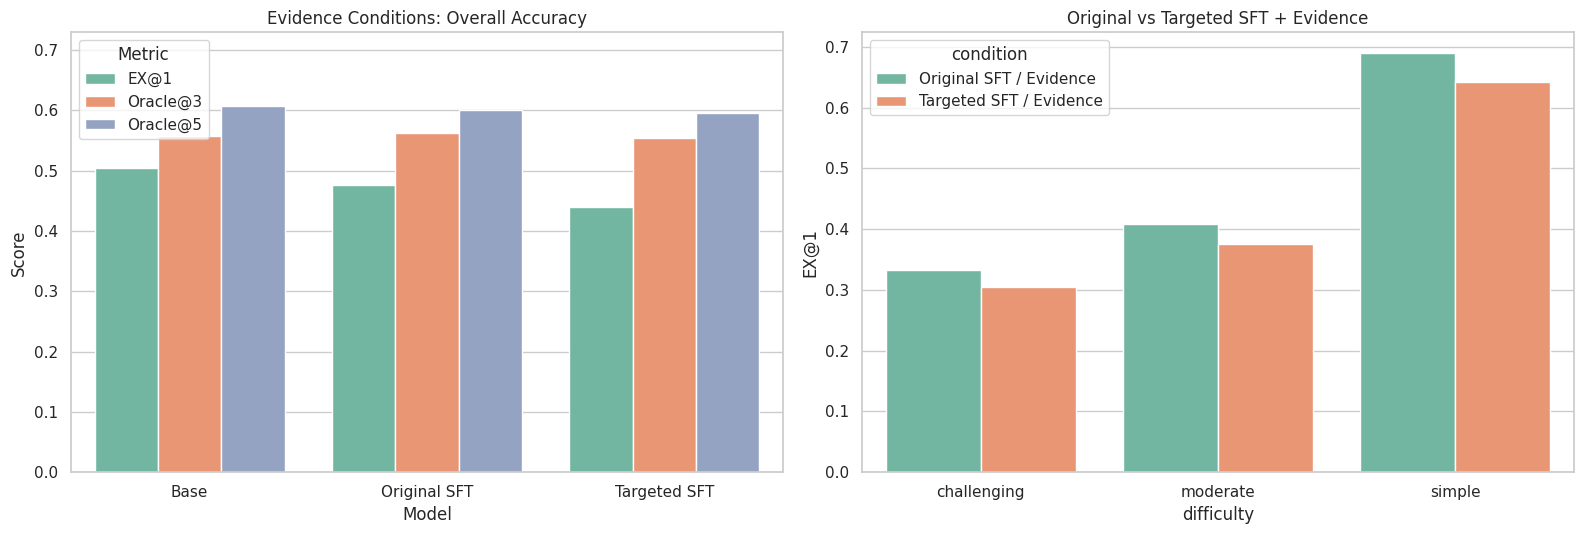

Saved chart: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_targeted_sft_final_comparison_v1/targeted_sft_final_comparison.png


In [41]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

evidence_summary = summary_table.loc[summary_table["Evidence"] == "Yes"].copy()
evidence_long = evidence_summary.melt(
    id_vars=["Experiment", "Model", "Evidence"],
    value_vars=["EX@1", "Oracle@3", "Oracle@5"],
    var_name="Metric",
    value_name="Score",
)
sns.barplot(data=evidence_long, x="Model", y="Score", hue="Metric", ax=axes[0], palette="Set2")
axes[0].set_ylim(0, min(1.0, max(0.1, evidence_long["Score"].max() * 1.20)))
axes[0].set_title("Evidence Conditions: Overall Accuracy")

sns.barplot(
    data=primary_by_difficulty,
    x="difficulty",
    y="ex_at_1",
    hue="condition",
    ax=axes[1],
    palette="Set2",
)
axes[1].set_title("Original vs Targeted SFT + Evidence")
axes[1].set_ylabel("EX@1")

plt.tight_layout()
chart_path = PROJECT_DIR / "targeted_sft_final_comparison.png"
fig.savefig(chart_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved chart:", chart_path)

## 19. Save and inspect Targeted-SFT improvements and regressions

In [42]:
PRIMARY_EFFECT = "targeted_vs_original_with_evidence"
change_column = f"change_ex_at_1_{PRIMARY_EFFECT}"
inspection_columns = [
    "position", "source_index", "db_id", "difficulty", "question", "evidence",
    "predicted_sql_sft_with_evidence",
    "predicted_sql_targeted_sft_with_evidence",
    "gold_sql", change_column,
]

targeted_improvements = six_way.loc[
    six_way[change_column] == "improved", inspection_columns
].copy()
targeted_regressions = six_way.loc[
    six_way[change_column] == "regressed", inspection_columns
].copy()

atomic_write_csv(
    targeted_improvements,
    PROJECT_DIR / "targeted_vs_original_with_evidence_improvements.csv",
)
atomic_write_csv(
    targeted_regressions,
    PROJECT_DIR / "targeted_vs_original_with_evidence_regressions.csv",
)

print("Targeted vs Original SFT + Evidence improvements:", len(targeted_improvements))
print("Targeted vs Original SFT + Evidence regressions:", len(targeted_regressions))
display(targeted_improvements.head(15))
display(targeted_regressions.head(15))

targeted_ev = RESULTS_BY_EXPERIMENT["targeted_sft_with_evidence"].copy()
oracle_recoveries = targeted_ev.loc[
    ~bool_series(targeted_ev["ex_at_1"]) & bool_series(targeted_ev["oracle_at_5"])
].copy()
atomic_write_csv(
    oracle_recoveries,
    PROJECT_DIR / "targeted_sft_with_evidence_oracle5_recoveries.csv",
)
print("Targeted SFT + Evidence Oracle@5 recoveries after EX@1 failure:", len(oracle_recoveries))

Targeted vs Original SFT + Evidence improvements: 7
Targeted vs Original SFT + Evidence regressions: 25


,position,source_index,db_id,difficulty,question,evidence,predicted_sql_sft_with_evidence,predicted_sql_targeted_sft_with_evidence,gold_sql,change_ex_at_1_targeted_vs_original_with_evidence
77,77,77,student_club,challenging,Write the full names of students who received funds on the date of 9/9/2019 and include the amount received.,"full name refers to first_name, last_name, amount of funds received refers to amount, received funds on date refers to date_received","SELECT T1.first_name, T1.last_name, T2.amount FROM member AS T1 INNER JOIN income AS T2 ON T1.member_id = T2.link_to_member WHERE T2.date_received = '9/9/2019'","SELECT T1.first_name, T1.last_name, T2.amount FROM member AS T1 INNER JOIN income AS T2 ON T1.member_id = T2.link_to_member WHERE T2.date_received = '2019-0...","SELECT DISTINCT T3.first_name, T3.last_name, T4.amount FROM event AS T1 INNER JOIN attendance AS T2 ON T1.event_id = T2.link_to_event INNER JOIN member AS T...",improved
198,198,198,formula_1,moderate,State the driver with the most points scored. Find his full name with that points.,the most points scored refers to max(points); Full name of the driver refers to drivers.forename and drivers.surname;,"SELECT T1.forename, T1.surname, T2.points FROM drivers AS T1 INNER JOIN results AS T2 ON T1.driverid = T2.driverid ORDER BY T2.points DESC LIMIT 1","SELECT T1.forename, T1.surname, T2.points FROM drivers AS T1 INNER JOIN driverstandings AS T2 ON T1.driverid = T2.driverid ORDER BY T2.points DESC LIMIT 1","SELECT T3.forename, T3.surname, T2.points FROM races AS T1 INNER JOIN driverStandings AS T2 ON T2.raceId = T1.raceId INNER JOIN drivers AS T3 ON T3.driverId...",improved
315,315,315,codebase_community,moderate,Which user made a post titled 'Understanding what Dassault iSight is doing?' and how much is the reputation of the user?,"""Understanding what Dassault iSight is doing?"" is the Title of post; user refers to DisplayName;","SELECT T1.DisplayName, T2.Reputation FROM users AS T1 INNER JOIN posts AS T2 ON T1.Id = T2.OwnerUserId WHERE T2.Title = 'Understanding what Dassault iSight ...","SELECT T1.DisplayName, T1.Reputation FROM users AS T1 INNER JOIN posts AS T2 ON T1.Id = T2.OwnerUserId WHERE T2.Title = 'Understanding what Dassault iSight ...","SELECT T1.DisplayName, T1.Reputation FROM users AS T1 INNER JOIN posts AS T2 ON T1.Id = T2.OwnerUserId WHERE T2.Title = 'Understanding what Dassault iSight ...",improved
326,326,326,codebase_community,challenging,"Among posts by Harvey Motulsky and Noah Snyder, which one has higher popularity?",Has higher popularity means the post has higher view count ; calculation = MAX(SUM(ViewCount)) where DisplayName = 'Harvey Motulsky' OR DisplayName = 'Noah ...,SELECT SUM(T2.ViewCount) FROM users AS T1 INNER JOIN posts AS T2 ON T1.Id = T2.OwnerUserId WHERE T1.DisplayName = 'Harvey Motulsky' OR T1.DisplayName = 'Noa...,"SELECT T2.DisplayName FROM posts AS T1 INNER JOIN users AS T2 ON T1.OwnerUserId = T2.Id WHERE T2.DisplayName IN ('Harvey Motulsky', 'Noah Snyder') GROUP BY ...",SELECT T1.DisplayName FROM users AS T1 INNER JOIN postHistory AS T2 ON T1.Id = T2.UserId INNER JOIN posts AS T3 ON T2.PostId = T3.Id WHERE T1.DisplayName = ...,improved
353,353,353,card_games,moderate,Calculate the percentage of the cards availabe in Chinese Simplified.,"Chinese Simplified' is the language; percentage = Divide(Sum(id where language = 'Chinese Simplified'), Count(id)) *100",SELECT CAST(COUNT(CASE WHEN T2.language = 'Chinese Simplified' THEN 1 ELSE NULL END) AS REAL) * 100 / COUNT(T1.id) FROM foreign_data AS T1 INNER JOIN sets A...,SELECT CAST(COUNT(CASE WHEN T2.language = 'Chinese Simplified' THEN 1 ELSE NULL END) AS REAL) * 100 / COUNT(T1.id) FROM cards AS T1 INNER JOIN foreign_data ...,SELECT CAST(SUM(CASE WHEN T2.language = 'Chinese Simplified' THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(T1.id) FROM cards AS T1 INNER JOIN foreign_data AS T2...,improved
394,394,394,card_games,moderate,Which cards are ranked 1st on EDHRec? List all of

,position,source_index,db_id,difficulty,question,evidence,predicted_sql_sft_with_evidence,predicted_sql_targeted_sft_with_evidence,gold_sql,change_ex_at_1_targeted_vs_original_with_evidence
8,8,8,debit_card_specializing,simple,How much did customer 6 consume in total between August and November 2013?,Between August And November 2013 refers to Between 201308 And 201311; The first 4 strings of the Date values in the yearmonth table can represent year; The ...,SELECT SUM(Consumption) FROM yearmonth WHERE CustomerID = 6 AND Date BETWEEN '201308' AND '201311',SELECT SUM(Consumption) FROM yearmonth WHERE CustomerID = 6 AND Date LIKE '201308%' OR Date LIKE '201309%' OR Date LIKE '201310%' OR Date LIKE '201311%',SELECT SUM(Consumption) FROM yearmonth WHERE CustomerID = 6 AND Date BETWEEN '201308' AND '201311',regressed
24,24,24,debit_card_specializing,simple,What is the percentage of the customers who used EUR in 2012/8/25?,'2012/8/25' can be represented by '2012-08-25',SELECT CAST(SUM(CASE WHEN T2.Currency = 'EUR' THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(T1.CustomerID) FROM transactions_1k AS T1 INNER JOIN customers AS T2...,SELECT CAST(SUM(CASE WHEN T1.Currency = 'EUR' THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(T1.CustomerID) FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1...,"SELECT CAST(SUM(IIF(T2.Currency = 'EUR', 1, 0)) AS FLOAT) * 100 / COUNT(T1.CustomerID) FROM transactions_1k AS T1 INNER JOIN customers AS T2 ON T1.CustomerI...",regressed
33,33,33,student_club,moderate,List all the names of events that had an attendance of over 20 students but were not fundraisers.,name of events refers to event_name; attendance of over 20 students COUNT(event_id) > 20.,SELECT T1.event_name FROM event AS T1 INNER JOIN attendance AS T2 ON T1.event_id = T2.link_to_event WHERE T1.type != 'fundraiser' GROUP BY T1.event_id HAVIN...,SELECT T1.event_name FROM event AS T1 INNER JOIN attendance AS T2 ON T1.event_id = T2.link_to_event WHERE T1.type != 'fundraiser' GROUP BY T1.event_name HAV...,SELECT T1.event_name FROM event AS T1 INNER JOIN attendance AS T2 ON T1.event_id = T2.link_to_event GROUP BY T1.event_id HAVING COUNT(T2.link_to_event) > 20...,regressed
38,38,38,student_club,moderate,Calculate the difference of the total amount spent in all events by the Student_Club in year 2019 and 2020.,The first 4 strings of the event_date values in the event table can represent year; The difference of the total amount spent = SUBTRACT(spent where YEAR(eve...,"SELECT SUM(CASE WHEN STRFTIME('%Y', T1.event_date) = '2019' THEN T2.spent ELSE 0 END) - SUM(CASE WHEN STRFTIME('%Y', T1.event_date) = '2020' THEN T2.spent E...","SELECT SUM(CASE WHEN STRFTIME('%Y', T1.event_date) = '2019' THEN T2.spent ELSE 0 END) - SUM(CASE WHEN STRFTIME('%Y', T1.event_date) = '2020' THEN T2.spent E...","SELECT SUM(CASE WHEN SUBSTR(T1.event_date, 1, 4) = '2019' THEN T2.spent ELSE 0 END) - SUM(CASE WHEN SUBSTR(T1.event_date, 1, 4) = '2020' THEN T2.spent ELSE ...",regressed
67,67,67,student_club,simple,Mention the total expense used on 8/20/2019.,total expense refers SUM(cost) where expense_date = '2019-08-20',SELECT SUM(CASE WHEN expense_date = '2019-08-20' THEN cost ELSE 0 END) FROM expense,"SELECT SUM(CAST(REPLACE(SUBSTR(cost, 4), ',', '') AS REAL)) FROM expense WHERE expense_date = '2019-08-20'",SELECT SUM(cost) FROM expense WHERE expense_date = '2019-08-20',regressed
127,127,127,thrombosis_prediction,challenging,"For the patients with a normal range of creatinine phosphokinase, how many of them have a positive measure of degree of coagulation?",normal range of creatinine phosphokinase refers to CPK < 250; positive measure of degree of coagulation refers to KCT = '+' or RVVT = '+' or LAC = '+' ;,SELECT COUNT(T1.ID) FROM Examination AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID WHERE T2.CPK < 250 AND (T1.KCT = '+' OR T1.RVVT = '+' OR T1.LAC = '+'),SELECT COUNT(DISTINCT T1.ID) FROM Examination AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID WHERE T2.CPK < 250 AND (T1.KCT 

Targeted SFT + Evidence Oracle@5 recoveries after EX@1 failure: 78


## 20. Write the final machine-readable comparison summary

In [43]:
comparison_summary = {
    "dataset": {
        "id": HF_DATASET_ID,
        "revision": HF_REVISION,
        "split": HF_SPLIT,
        "size": int(len(six_way)),
        "unique_databases": int(six_way["db_id"].nunique()),
        "sha256": DATASET_SHA256,
        "status": "iterative development benchmark; not an untouched blind test",
    },
    "targeted_training": {
        "run_name": TARGETED_TRAINING_RUN_DIR.name,
        "selected_checkpoint_step": selected_step,
        "selected_checkpoint_macro_ex": TARGETED_TRAINING_CONFIG["selected_checkpoint_macro_ex"],
        "best_loss_checkpoint": TARGETED_TRAINING_CONFIG.get("best_loss_checkpoint"),
        "best_loss_metric": TARGETED_TRAINING_CONFIG.get("best_loss_metric"),
        "training_peak_gpu_memory_gb": TARGETED_TRAINING_CONFIG.get("peak_gpu_memory_gb"),
        "evaluation_peak_allocated_gpu_memory_gb": evaluation_peak_gpu_gb,
    },
    "candidate_protocol": {
        "num_candidates": NUM_CANDIDATES,
        "candidate_1": "greedy; used for EX@1",
        "candidates_2_to_5": {
            "method": "seeded multinomial sampling",
            "temperature": SAMPLING_TEMPERATURE,
            "top_p": SAMPLING_TOP_P,
            "seed_rule": "SEED + position",
        },
        "oracle_at_k": "at least one execution-correct SQL among candidates 1..K",
    },
    "experiments": SUMMARIES_BY_EXPERIMENT,
    "paired_effects": paired_effects.to_dict(orient="records"),
    "interactions": interaction_summary.to_dict(orient="records"),
    "primary_comparison": {
        "control": "sft_with_evidence",
        "treatment": "targeted_sft_with_evidence",
        "improvements_ex_at_1": int(len(targeted_improvements)),
        "regressions_ex_at_1": int(len(targeted_regressions)),
    },
    "interpretation": {
        "primary_deployable_metric": "EX@1 from greedy candidate 1",
        "oracle_warning": "Oracle@K assumes a perfect selector and is an upper bound.",
        "paired_delta_definition": "treatment score - control score",
        "mcnemar_test": "exact two-sided binomial test on discordant paired outcomes",
        "bootstrap_ci": "paired 10000-sample percentile bootstrap",
    },
}
atomic_write_json(
    comparison_summary,
    PROJECT_DIR / "targeted_sft_final_comparison_summary.json",
)

result_files = sorted(
    path for path in PROJECT_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in {".csv", ".json", ".jsonl", ".png"}
)

print("Evaluation complete. Result files:")
for path in result_files:
    print(f" - {path.name} ({path.stat().st_size / 1024:.1f} KB)")

print("\nReview first:")
print(" - six_way_metric_summary.csv")
print(" - primary_targeted_sft_paired_effects.csv")
print(" - primary_comparison_by_difficulty.csv")
print(" - targeted_sft_final_comparison_summary.json")
print(" - targeted_vs_original_with_evidence_improvements.csv")
print(" - targeted_vs_original_with_evidence_regressions.csv")

Evaluation complete. Result files:
 - baseline_no_evidence_all_candidates.json (458.2 KB)
 - baseline_no_evidence_official_predictions_candidate1.json (107.5 KB)
 - baseline_no_evidence_summary.json (3.0 KB)
 - baseline_with_evidence_all_candidates.json (465.1 KB)
 - baseline_with_evidence_official_predictions_candidate1.json (109.1 KB)
 - baseline_with_evidence_summary.json (3.0 KB)
 - interaction_summary_all_metrics.csv (0.6 KB)
 - paired_effects_all_metrics.csv (4.8 KB)
 - primary_comparison_by_difficulty.csv (0.9 KB)
 - primary_targeted_sft_paired_effects.csv (1.3 KB)
 - sft_no_evidence_all_candidates.json (471.0 KB)
 - sft_no_evidence_official_predictions_candidate1.json (110.6 KB)
 - sft_no_evidence_summary.json (3.0 KB)
 - sft_with_evidence_all_candidates.json (472.8 KB)
 - sft_with_evidence_official_predictions_candidate1.json (110.9 KB)
 - sft_with_evidence_summary.json (3.0 KB)
 - six_way_by_database.csv (8.9 KB)
 - six_way_by_difficulty.csv (2.5 KB)
 - six_way_metric_summary

## Interpretation order

1. Compare **Targeted SFT + Evidence** with **Original SFT + Evidence** on EX@1. This is the primary result.
2. Check improved versus regressed paired examples and the exact McNemar p-value. A positive point estimate without paired support should be reported cautiously.
3. Check moderate and challenging subsets. The targeted run was motivated by the Original-SFT moderate degradation, so an overall gain driven only by simple questions is insufficient.
4. Compare Oracle@5 − EX@1. A large remaining gap supports a reranking/verification follow-up; a small gap indicates candidate generation is still the bottleneck.
5. Check no-evidence performance to determine whether targeted sampling learned general SQL capability or only changed evidence use.
6. Do not run a second epoch merely because training loss was still moving. Only consider it if the full 500-example evaluation is promising but clearly underfit, and use a new isolated run name.

MiniDev500 has already influenced failure-mode selection. Report it as a public development benchmark and keep this limitation explicit in the README and experiment log.